In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Importing necessary modules
import numpy as np
from itertools import product
from matplotlib import pyplot as plt
from RL4CRN.utils.utils import performance_metric
from RL4CRN.rewards.deterministic import dynamic_tracking_error
from RL4CRN.iocrns.mass_action_iocrn import MassActionIOCRN

In [3]:
# Construct using the stoichiometry matrices and parameters
species_labels = ['X_1', 'X_2', 'Z_1', 'Z_2']
inputs_labels = ['u_1', 'u_2', 'u_3']
S_R = np.array([[1, 1, 0, 0, 0, 0, 0, 0, 0], 
                [0, 0, 1, 0, 1, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 1, 1, 1, 0],
                [0, 0, 0, 0, 0, 1, 0, 0, 1]], dtype=np.int8)
S_P = np.array([[0, 1, 0, 0, 0, 0, 1, 0, 0], 
                [0, 1, 0, 0, 1, 0, 0, 0, 0],
                [0, 0, 0, 1, 0, 0, 1, 0, 0],
                [0, 0, 0, 0, 1, 0, 0, 0, 0]], dtype=np.int8)
gamma_1 = 5.0; k_1 = 1.0; gamma_2 = 0.5; mu = 10.0; theta = 1.0; eta = 0.1; k = 1.0; delta = 0.0
c = np.array([gamma_1, k_1, gamma_2, mu, theta, eta, k, delta, delta], dtype=np.float32)
S_I = np.array([[0, 0, 0, 1, 0, 0, 0, 0, 0], 
                [1, 0, 0, 0, 0, 0, 0, 0, 0], 
                [0, 0, 1, 0, 0, 0, 0, 0, 0]], dtype=np.int8)
o = np.array([1, 2], dtype=np.int8)
iocrn_0 = MassActionIOCRN(S_R, S_P, c, S_I, o, species_labels, inputs_labels)

In [4]:
# Print the constructed IOCRN
print(iocrn_0)

Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['X_1', 'X_2', 'Z_1', 'Z_2'] 
Output Species: ['X_1', 'X_2'] 
Reaction 0: X_1 -> 0 ; Rate Constant: 5.0u_2 
Reaction 1: X_1 -> X_1 + X_2 ; Rate Constant: 1.0 
Reaction 2: X_2 -> 0 ; Rate Constant: 0.5u_3 
Reaction 3: 0 -> Z_1 ; Rate Constant: 10.0u_1 
Reaction 4: X_2 -> X_2 + Z_2 ; Rate Constant: 1.0 
Reaction 5: Z_1 + Z_2 -> 0 ; Rate Constant: 0.10000000149011612 
Reaction 6: Z_1 -> X_1 + Z_1 ; Rate Constant: 1.0 
Reaction 7: Z_1 -> 0 ; Rate Constant: 0.0 
Reaction 8: Z_2 -> 0 ; Rate Constant: 0.0 



In [5]:
# Simulate Dynamics for a range of inputs but a single initial condition
u_list = [np.array([0.5, 1, 1], dtype=np.float32), np.array([1, 1, 1], dtype=np.float32)]
x0_list = [np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)]
time_horizon = np.linspace(0, 200.0, 1000, dtype=np.float32)
t, x_list, y_list, task_info = iocrn_0.transient_response(u_list, x0_list, time_horizon)
iocrn_0.print_task_info('sizes')

type --- Type: str, Value: transient response
inputs --- Type: list of numpy arrays, List size: 2, Numpy Arrays shape: (3,)
initial conditions --- Type: list of numpy arrays, List size: 1, Numpy Arrays shape: (4,)
time_horizon --- Type: ndarray, Shape: (1000,)
trajectories --- Type: list of numpy arrays, List size: 2, Numpy Arrays shape: (4, 1000)
outputs --- Type: list of numpy arrays, List size: 2, Numpy Arrays shape: (2, 1000)


1.517389037408312


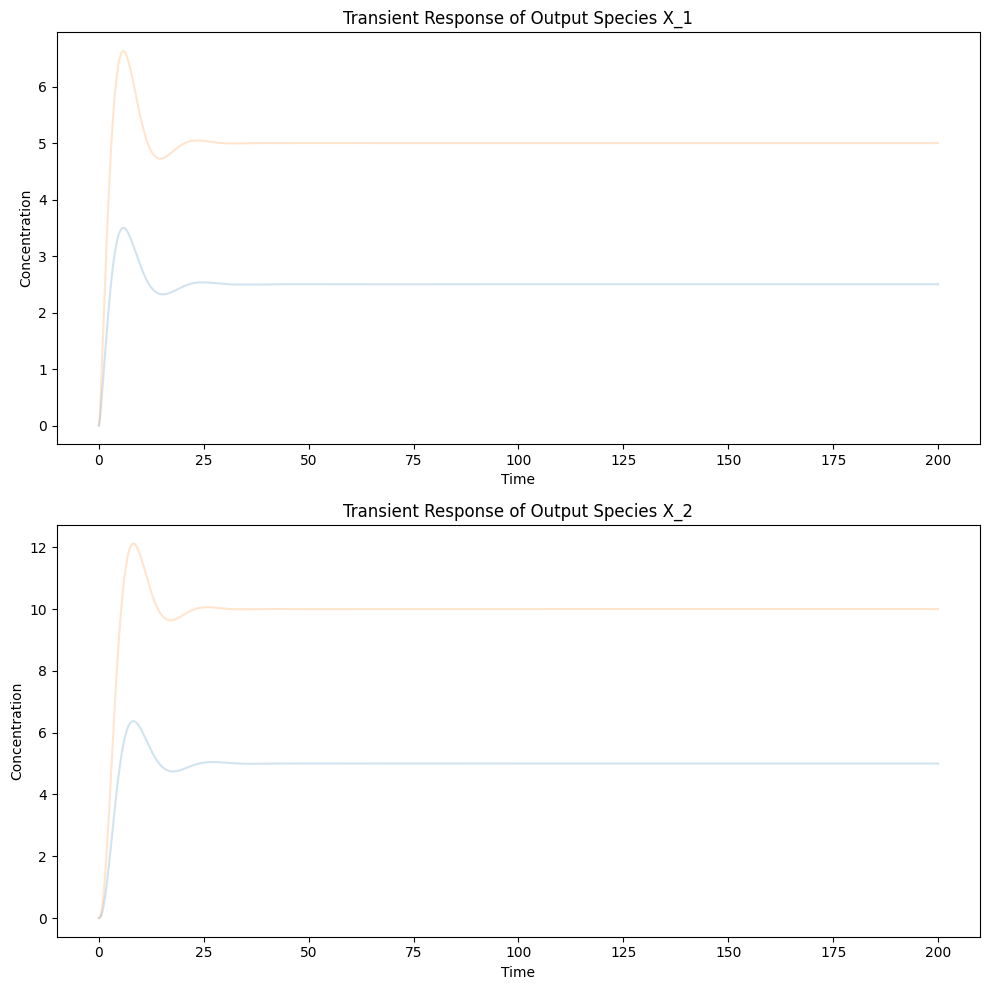

In [6]:
# Compute tracking error using the performance metric function
fig, ax = iocrn_0.plot_transient_response(alpha = 0.2)
r_list = [np.array([5.0, 5.0], dtype=np.float32), np.array([10.0, 10.0], dtype=np.float32)]
w = np.ones((iocrn_0.q, t.shape[0]), dtype=np.float32) 
w[:,0:w.shape[1]//4] = 0.2
performance = performance_metric(r_list, y_list, w)
print(performance)


In [7]:
# Compute tracking error using the dynamic_tracking_error function
performance, task_info = dynamic_tracking_error(iocrn_0, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e4)
print(performance)
iocrn_0.print_task_info('sizes')

1.517389037408312
type --- Type: str, Value: transient response
inputs --- Type: list of numpy arrays, List size: 2, Numpy Arrays shape: (3,)
initial conditions --- Type: list of numpy arrays, List size: 1, Numpy Arrays shape: (4,)
time_horizon --- Type: ndarray, Shape: (1000,)
trajectories --- Type: list of numpy arrays, List size: 2, Numpy Arrays shape: (4, 1000)
outputs --- Type: list of numpy arrays, List size: 2, Numpy Arrays shape: (2, 1000)
reward --- Type: float64, Value: 1.517389037408312
setpoint --- Type: list of numpy arrays, List size: 2, Numpy Arrays shape: (2,)
reward type --- Type: str, Value: dynamic_tracking_error
